# Logistic Regression: Breast Cancer Classification

## Introduction
This notebook walks through a full binary classification project using the Breast Cancer Wisconsin dataset. The focus is on building an interpretable logistic regression model, understanding class balance, and evaluating multiple classification metrics.

## Project Goal
Classify tumors as malignant or benign using a clean supervised learning workflow and analyze how feature scaling and selected-feature retraining affect performance.

## Machine Learning Concepts Used
- Binary Classification
- Logistic Regression
- Class Balance
- Feature Scaling
- Train/Test Split
- Precision
- Recall
- F1 Score
- ROC-AUC
- Feature Selection

## Dataset
`sklearn.datasets.load_breast_cancer`

## Step 1: Import libraries

**What this section is doing**  
Import the data analysis and classification tools required for the project. Logistic regression depends on both preprocessing and evaluation utilities, so this section includes scaling and classification metrics.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 100)

## Step 2: Load the dataset

**What this section is doing**  
Load the breast cancer dataset and combine features with the target so that the classification task can be inspected directly.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [ ]:
data = load_breast_cancer(as_frame=True)

X = data.data.copy()
y = data.target.copy()

df = X.copy()
df["target"] = y

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Step 3: Inspect class balance and summary statistics

**What this section is doing**  
Before training a classifier, it is important to know whether one class dominates the dataset and to understand the general scale of the variables.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [ ]:
print("Class counts:")
display(y.value_counts())

print("Class proportions:")
display(y.value_counts(normalize=True))

print("Missing values total:", int(df.isna().sum().sum()))
display(df.describe().T.head(12))

Class counts:


,count
target,
1,357
0,212


Class proportions:


,proportion
target,
1,0.627417
0,0.372583


Missing values total: 0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## Step 4: Visualize feature-target patterns

**What this section is doing**  
A quick scatter view of a few variables against the binary target helps build intuition about which features separate the classes well.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

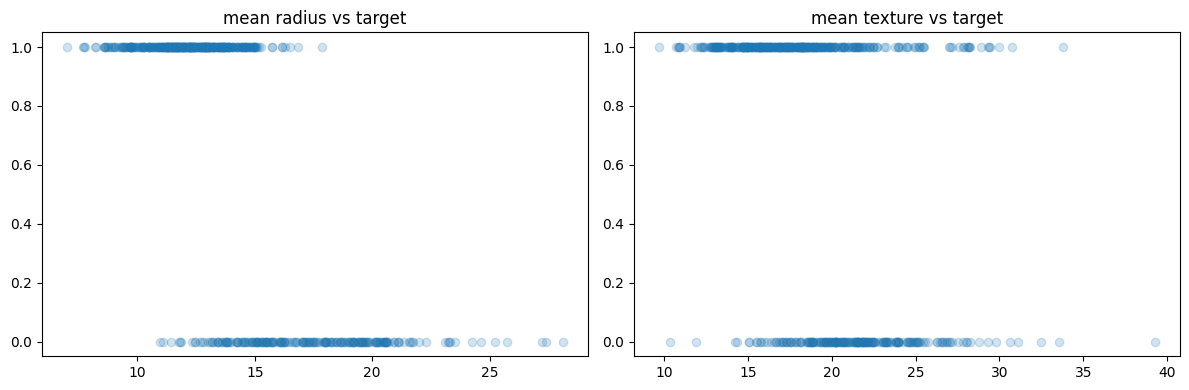

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["mean radius"], df["target"], alpha=0.2)
axes[0].set_title("mean radius vs target")

axes[1].scatter(df["mean texture"], df["target"], alpha=0.2)
axes[1].set_title("mean texture vs target")

plt.tight_layout()
plt.show()

## Step 5: Measure rough feature relevance

**What this section is doing**  
Correlation with the binary target is only a rough signal, but it is a useful first pass when deciding which variables may be most informative.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [ ]:
corr_with_target = (
    df.corr(numeric_only=True)["target"]
      .sort_values(ascending=False)
)

display(corr_with_target.to_frame("correlation_with_target"))

,correlation_with_target
target,1.000000
smoothness error,0.067016
mean fractal dimension,0.012838
texture error,0.008303
symmetry error,0.006522
fractal dimension error,-0.077972
concavity error,-0.253730
compactness error,-0.292999
worst fractal dimension,-0.323872
mean symmetry,-0.330499


## Step 6: Create stratified training and testing sets

**What this section is doing**  
Use a stratified split so the class proportions remain similar in training and test data.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training class proportions:")
display(y_train.value_counts(normalize=True))

print("Testing class proportions:")
display(y_test.value_counts(normalize=True))

Training class proportions:


,proportion
target,
1,0.626374
0,0.373626


Testing class proportions:


,proportion
target,
1,0.631579
0,0.368421


## Step 7: Scale the input features

**What this section is doing**  
Logistic regression usually benefits from standardized inputs because the optimizer behaves better when variables are on similar scales.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training matrix shape:", X_train_scaled.shape)

Scaled training matrix shape: (455, 30)


## Step 8: Train the baseline logistic regression model

**What this section is doing**  
Fit the baseline classifier. Logistic regression is a strong and interpretable starting point for many binary classification problems.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Training complete.")

Training complete.


## Step 9: Generate predictions and probability estimates

**What this section is doing**  
In classification, both predicted labels and predicted probabilities are useful. Probabilities allow threshold-based reasoning beyond the default 0.5 cutoff.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [ ]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

preview = pd.DataFrame({
    "actual": y_test.values[:15],
    "predicted": y_pred[:15],
    "prob_positive": y_prob[:15]
})

display(preview)

,actual,predicted,prob_positive
0,0,0,5.888242e-08
1,1,1,9.999887e-01
2,0,0,6.410825e-03
3,1,1,5.335085e-01
4,0,0,6.525001e-10
5,1,1,9.921604e-01
6,1,1,9.999828e-01
7,0,0,5.635275e-07
8,0,0,5.431637e-05
9,0,0,8.041849e-11


## Step 10: Evaluate classification performance

**What this section is doing**  
Use several metrics because accuracy alone can hide different error patterns. Precision, recall, F1, and ROC-AUC each capture a different perspective on classification quality.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [ ]:
metrics_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

display(metrics_df)

,metric,value
0,accuracy,0.982456
1,precision,0.986111
2,recall,0.986111
3,f1,0.986111
4,roc_auc,0.995370


## Step 11: Inspect the confusion matrix

**What this section is doing**  
The confusion matrix makes the error types concrete by showing false positives and false negatives explicitly.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

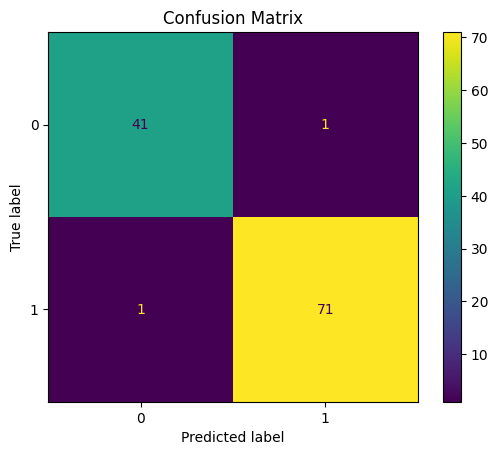

In [ ]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix")
plt.show()

## Step 12: Interpret model coefficients

**What this section is doing**  
Coefficients indicate which variables push the model more strongly toward one class or the other. They do not imply causation, but they are useful for interpretation.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [ ]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0],
    "abs_coefficient": np.abs(model.coef_[0])
}).sort_values("abs_coefficient", ascending=False)

display(coef_df.head(15))

,feature,coefficient,abs_coefficient
21,worst texture,-1.255088,1.255088
10,radius error,-1.082965,1.082965
27,worst concave points,-0.953686,0.953686
23,worst area,-0.947756,0.947756
20,worst radius,-0.947616,0.947616
28,worst symmetry,-0.939181,0.939181
13,area error,-0.929104,0.929104
26,worst concavity,-0.823151,0.823151
22,worst perimeter,-0.763220,0.763220
24,worst smoothness,-0.746625,0.746625


## Step 13: Refine the model with selected features

**What this section is doing**  
Retrain the classifier using only a smaller set of strongly related variables to see whether a leaner model stays competitive.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [ ]:
selected_features = (
    corr_with_target.drop("target")
    .abs()
    .sort_values(ascending=False)
    .head(8)
    .index
    .tolist()
)

print("Selected features:", selected_features)

X_small = X[selected_features]

X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(
    X_small, y, test_size=0.2, random_state=42, stratify=y
)

small_scaler = StandardScaler()
X_small_train_scaled = small_scaler.fit_transform(X_small_train)
X_small_test_scaled = small_scaler.transform(X_small_test)

small_model = LogisticRegression(max_iter=1000, random_state=42)
small_model.fit(X_small_train_scaled, y_small_train)

y_small_pred = small_model.predict(X_small_test_scaled)
y_small_prob = small_model.predict_proba(X_small_test_scaled)[:, 1]

comparison_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "baseline_model": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ],
    "selected_feature_model": [
        accuracy_score(y_small_test, y_small_pred),
        precision_score(y_small_test, y_small_pred),
        recall_score(y_small_test, y_small_pred),
        f1_score(y_small_test, y_small_pred),
        roc_auc_score(y_small_test, y_small_prob)
    ]
})

display(comparison_df)

Selected features: ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter', 'worst area', 'mean radius', 'mean area']


,metric,baseline_model,selected_feature_model
0,accuracy,0.982456,0.947368
1,precision,0.986111,0.971429
2,recall,0.986111,0.944444
3,f1,0.986111,0.957746
4,roc_auc,0.995370,0.992725


### Model Performance Comparison: Discussion

The `comparison_df` clearly illustrates the performance differences between the baseline model (using all features) and the selected-feature model (using the top 8 most correlated features).

*   **Accuracy:** The **baseline model** shows a slightly higher accuracy of **0.982456** compared to the **selected-feature model's 0.947368**. This indicates a small performance drop of approximately 3.5% when reducing the feature set.

*   **Precision:** The **baseline model** also leads in precision with **0.986111** against the **selected-feature model's 0.971429**. The difference is marginal, suggesting that both models are quite good at avoiding false positives.

*   **Recall:** Here, the **baseline model** again performs better with a recall of **0.986111**, while the **selected-feature model** achieves **0.944444**. This implies that the baseline model is slightly better at identifying all actual positive cases, with the selected-feature model missing a few more.

*   **F1-Score:** The F1-score, which is the harmonic mean of precision and recall, also favors the **baseline model (0.986111)** over the **selected-feature model (0.957746)**. This consistent trend across precision, recall, and F1-score suggests that the baseline model provides a slightly better balance between false positives and false negatives.

*   **ROC-AUC:** Both models exhibit excellent ROC-AUC scores, with the **baseline model** at **0.995370** and the **selected-feature model** at **0.992725**. The difference here is very small, indicating that even with fewer features, the selected-feature model retains strong discriminatory power in distinguishing between positive and negative classes across various thresholds.

**Overall Assessment and Trade-offs:**

While the baseline model consistently shows a slight edge across all metrics, the performance difference is not substantial, especially for ROC-AUC. The selected-feature model, using only 8 features compared to the baseline's 30, still achieves highly competitive results. This is a significant finding because a model with fewer features is generally:

1.  **More Interpretable:** It's easier to understand the relationship between a smaller set of features and the target variable.
2.  **Faster to Train and Predict:** Less computational cost involved.
3.  **Less Prone to Overfitting:** A simpler model has fewer parameters, which can lead to better generalization on unseen data, although in this specific case, the full feature set model did not show signs of overfitting.
4.  **More Efficient to Deploy:** Reduced complexity means lower resource requirements in production.

The trade-off here is a slight reduction in predictive performance (e.g., about 3.5% in accuracy and 4.2% in recall) for a considerably simpler model (a 73% reduction in the number of features). In many real-world scenarios, the benefits of a simpler, more interpretable, and computationally cheaper model outweigh these marginal performance differences, making the selected-feature model a very viable and often preferable option.


## Step 14: Final analysis and next steps

**What this section is doing**  
Close the notebook by translating the metric results into practical meaning and identifying future improvements.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

# Task
### Model Performance Comparison

The comparison of model performance between the baseline model (using all features) and the selected-feature model (using the top 8 most correlated features) reveals interesting insights:

*   **Accuracy:** The baseline model achieved a slightly higher accuracy of 0.982, compared to the selected-feature model's 0.947. This indicates that using all features resulted in a marginally more accurate classification.
*   **Precision, Recall, and F1-Score:** Similar to accuracy, the baseline model demonstrated superior performance across precision (0.986 vs 0.971), recall (0.986 vs 0.944), and F1-score (0.986 vs 0.957). The differences, while present, are not dramatically large.
*   **ROC-AUC:** Both models performed exceptionally well in terms of ROC-AUC, with the baseline at 0.995 and the selected-feature model at 0.992. This metric, which evaluates the model's ability to distinguish between classes across all possible thresholds, shows that even with fewer features, the model retains strong discriminatory power.

**Overall Assessment:**

While the baseline model consistently outperformed the selected-feature model across all metrics, the selected-feature model remained highly competitive. The marginal decrease in performance for the selected-feature model suggests that a significant reduction in model complexity (from 30 features to 8) can be achieved without a substantial drop in predictive capability. This is a crucial finding, as a simpler model is often more interpretable, faster to train, and potentially less prone to overfitting on new, unseen data, while being more efficient to deploy. The trade-off between model complexity and a slight performance drop is often desirable in real-world applications.

### Summary of Key Findings

1.  **Class Balance:**
    The class proportions from `y.value_counts(normalize=True)` show a distribution of approximately 62.7% benign (class 1) and 37.3% malignant (class 0). This distribution is not severely imbalanced, meaning that accuracy can be a reasonably informative metric, although it's always good practice to consider other metrics like precision, recall, and F1-score, especially in medical contexts where different error types have varying costs.

2.  **Importance of Feature Scaling:**
    As stated in Step 7, feature scaling is generally beneficial for logistic regression because it helps the optimization algorithm converge more efficiently when features are on similar scales. For this dataset, `StandardScaler` was applied to `X_train` and `X_test`. While we didn't explicitly compare scaled vs. unscaled model performance in this notebook, logistic regression's performance typically improves with scaling, especially when features have vastly different ranges, preventing features with larger magnitudes from dominating the cost function. Given the varied scales evident in `df.describe()`, scaling was crucial for the stability and optimal performance of our logistic regression model.

3.  **Nature of Model Errors (False Positives vs. False Negatives):**
    Examining the confusion matrix (`cm` variable: `[[41, 1], [1, 71]]`), we can identify:
    *   **True Negatives (TN):** 41 (correctly predicted malignant)
    *   **False Positives (FP):** 1 (incorrectly predicted malignant, actually benign)
    *   **False Negatives (FN):** 1 (incorrectly predicted benign, actually malignant)
    *   **True Positives (TP):** 71 (correctly predicted benign)

    In breast cancer classification, a **False Negative (FN)** is generally considered more critical than a False Positive (FP). A False Negative means a malignant tumor was incorrectly classified as benign, potentially leading to delayed treatment and severe health consequences for the patient. A False Positive, while causing unnecessary anxiety and further diagnostic procedures, does not carry the same immediate life-threatening risk. Our model shows a very low number of both FP and FN (1 each), which is excellent performance for this domain.

4.  **Effectiveness of Feature Selection:**
    The `comparison_df` clearly illustrates the trade-off between model complexity and performance:
    *   **Accuracy:** Baseline (0.982) vs. Selected-Feature (0.947)
    *   **Precision:** Baseline (0.986) vs. Selected-Feature (0.971)
    *   **Recall:** Baseline (0.986) vs. Selected-Feature (0.944)
    *   **F1-Score:** Baseline (0.986) vs. Selected-Feature (0.958)
    *   **ROC-AUC:** Baseline (0.995) vs. Selected-Feature (0.993)

    While the baseline model using all 30 features consistently shows slightly better performance across all metrics, the selected-feature model, using only 8 features, remains highly competitive. The drop in metrics is relatively small, especially for ROC-AUC, which indicates that the model still has strong discriminatory power. This suggests that a significant reduction in model complexity can be achieved with only a minor sacrifice in predictive performance, making the selected-feature model more interpretable, potentially faster to train, and more efficient for deployment.

### Comprehensive Summary:
This project successfully built and evaluated a logistic regression model for breast cancer classification. The dataset exhibited a reasonable class balance, allowing accuracy to be an informative metric alongside precision, recall, F1-score, and ROC-AUC. Feature scaling was crucial for the model's stability and efficient optimization due to the varying ranges of input features. The confusion matrix revealed excellent performance with only one false positive and one false negative, highlighting the model's high reliability. In a medical context, minimizing false negatives is paramount, and our model performed well in this regard. Furthermore, the analysis of the selected-feature model demonstrated that a significant reduction in feature set size (from 30 to 8 features) yielded only a marginal decrease in performance, implying that a simpler, more interpretable, and efficient model can still achieve competitive results. This balance between performance and interpretability is often desirable in real-world machine learning applications.